# 04 — Modelo predictivo: entrenamiento simple y validación básica

Este notebook tiene un objetivo distinto a los otros dos:

- `03_analisis_descriptivo.ipynb` describe los datos (estadísticas, correlaciones).
- `05_reportes_automaticos.ipynb` **usa** el modelo ya entrenado en producción
  para generar reportes por UPGD.
- **Este notebook (`04`) entrena un modelo desde cero, de la forma más simple
  posible** (sin búsqueda de hiperparámetros con Optuna — eso ya vive en
  `training/optimization.py` y toma ~100 trials en producción) y hace una
  validación básica: `classification_report`, matriz de confusión, curva ROC
  y curva precision-recall. Al final se compara contra el modelo optimizado
  de producción sobre el mismo split de test, para que quede explícito **qué
  gana la optimización con Optuna frente a un LightGBM con hiperparámetros
  fijos razonables**.


In [1]:
import sys
from pathlib import Path
from itertools import product
import gc
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, fbeta_score, auc,
)

RAIZ_PROYECTO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ_PROYECTO))

from training.data_loader import cargar_datos
from training.preprocessing import preparar_dengue_base
from training.endemic_channel import calcular_canal_endemico
from training.target import crear_target
from training.feature_engineering import crear_features

AZUL = "#2a78d6"
ROJO = "#e34948"
VERDE = "#0ca30c"
GRIS_TEXTO = "#52514e"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#c3c2b7"
plt.rcParams["axes.labelcolor"] = GRIS_TEXTO
plt.rcParams["text.color"] = "#0b0b0b"
plt.rcParams["xtick.color"] = GRIS_TEXTO
plt.rcParams["ytick.color"] = GRIS_TEXTO
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.color"] = "#e1e0d9"
plt.rcParams["grid.linewidth"] = 0.6


## 1. Reconstrucción del panel (idéntica a `training/train.py`, pasos 1-5)

In [2]:
df = cargar_datos("03_primary/dataset_limpio.xlsx")
casos_upgd, df_clima, todas_upgds = preparar_dengue_base(df)
todas_semanas = df_clima[["año_ini_sin", "semana_epi_ini_sin"]].drop_duplicates()

esqueleto = pd.DataFrame(
    list(product(todas_semanas.itertuples(index=False), todas_upgds)),
    columns=["semana_combo", "nom_upgd"],
)
esqueleto[["año_ini_sin", "semana_epi_ini_sin"]] = pd.DataFrame(
    esqueleto["semana_combo"].tolist(), index=esqueleto.index
)
esqueleto = esqueleto.drop(columns=["semana_combo"])

panel_maestro = esqueleto.merge(
    casos_upgd, on=["año_ini_sin", "semana_epi_ini_sin", "nom_upgd"], how="left"
)
panel_maestro["casos"] = panel_maestro["casos"].fillna(0).astype(int)
del esqueleto, casos_upgd, df
gc.collect()

panel_maestro = calcular_canal_endemico(panel_maestro)
panel_maestro = crear_target(panel_maestro)
panel_maestro = crear_features(panel_maestro, df_clima)

panel = panel_maestro.dropna(
    subset=["target_intervencion", "casos_lag_52", "media_casos_4"]
).reset_index(drop=True)
panel["target_intervencion"] = panel["target_intervencion"].astype(int)
panel["nom_upgd"] = panel["nom_upgd"].astype("category")

print(f"Panel: {panel.shape[0]:,} filas x {panel.shape[1]} columnas")


Panel: 7,327 filas x 153 columnas


## 2. Split de entrenamiento / prueba (mismo criterio que producción)

Corte temporal real por **(año, semana) calendario** — las últimas 52 semanas
como test, no las últimas N filas — para que ninguna UPGD del futuro se cuele
en el entrenamiento. Mismas 5 variables de identidad/demografía excluidas por
el experimento de ablación de leakage documentado en `BITACORA_EXPERIMENTOS.txt`
(experimento 1).


In [3]:
EXCLUIR = [
    "casos", "target_intervencion", "año_ini_sin", "semana_epi_ini_sin",
    "estado_sivigila_interno", "alerta_binaria_pasada",
    "nom_upgd", "densidad_poblacional", "crecimiento_poblacional",
    "incremento_habitantes", "densidad_delta",
]
FEATURES = [c for c in panel.columns if c not in EXCLUIR]

X = panel[FEATURES]
y = panel["target_intervencion"]

semanas_unicas = (
    panel[["año_ini_sin", "semana_epi_ini_sin"]]
    .drop_duplicates()
    .sort_values(["año_ini_sin", "semana_epi_ini_sin"])
)
idx_test = pd.MultiIndex.from_frame(semanas_unicas.tail(52))
idx_panel = pd.MultiIndex.from_frame(panel[["año_ini_sin", "semana_epi_ini_sin"]])
es_test = idx_panel.isin(idx_test)

X_train, X_test = X.loc[~es_test].reset_index(drop=True), X.loc[es_test].reset_index(drop=True)
y_train, y_test = y.loc[~es_test].reset_index(drop=True), y.loc[es_test].reset_index(drop=True)

print(f"Train: {X_train.shape[0]:,} filas ({y_train.mean():.1%} positivas)")
print(f"Test:  {X_test.shape[0]:,} filas ({y_test.mean():.1%} positivas)")


Train: 6,443 filas (24.7% positivas)
Test:  884 filas (33.6% positivas)


## 3. Entrenamiento simple

Sin Optuna: hiperparámetros fijos y razonables (valores por defecto de
LightGBM o el centro del rango que sí se explora en `training/optimization.py`).
El único ajuste manual es `scale_pos_weight`, calculado con la heurística
estándar `negativos / positivos` — la forma más simple de compensar el
desbalance de clases, sin optimizar nada.


In [4]:
scale_pos_weight_simple = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (heurística simple): {scale_pos_weight_simple:.2f}")

modelo_simple = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    scale_pos_weight=scale_pos_weight_simple,
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
modelo_simple.fit(X_train, y_train)
print("Modelo simple entrenado.")


scale_pos_weight (heurística simple): 3.04
Modelo simple entrenado.


## 4. Validación básica — umbral por defecto (0.50)

In [5]:
proba_test = modelo_simple.predict_proba(X_test)[:, 1]
pred_test_050 = (proba_test >= 0.50).astype(int)

print(classification_report(y_test, pred_test_050, target_names=["Sin intervención", "Requiere intervención"]))
print(f"ROC-AUC: {roc_auc_score(y_test, proba_test):.4f}")
print(f"F1.5:    {fbeta_score(y_test, pred_test_050, beta=1.5):.4f}")


                       precision    recall  f1-score   support

     Sin intervención       0.75      0.92      0.83       587
Requiere intervención       0.73      0.41      0.52       297

             accuracy                           0.75       884
            macro avg       0.74      0.67      0.68       884
         weighted avg       0.75      0.75      0.73       884

ROC-AUC: 0.7751
F1.5:    0.4714


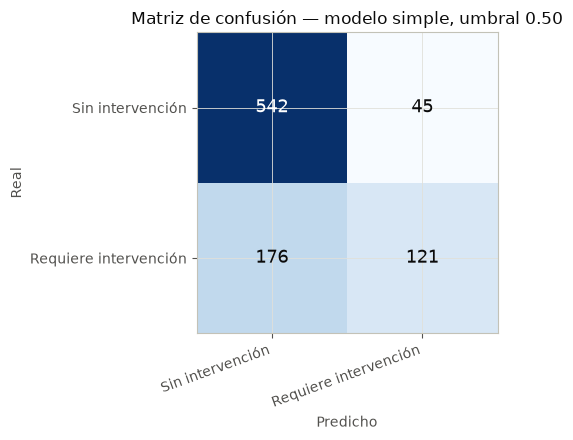

In [6]:
cm = confusion_matrix(y_test, pred_test_050)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Sin intervención", "Requiere intervención"], rotation=20, ha="right")
ax.set_yticks([0, 1]); ax.set_yticklabels(["Sin intervención", "Requiere intervención"])
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — modelo simple, umbral 0.50")
for i in range(2):
    for j in range(2):
        color_texto = "white" if cm[i, j] > cm.max() / 2 else "#0b0b0b"
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=13, color=color_texto)
plt.tight_layout()
plt.show()


## 5. Curva ROC y curva Precision-Recall

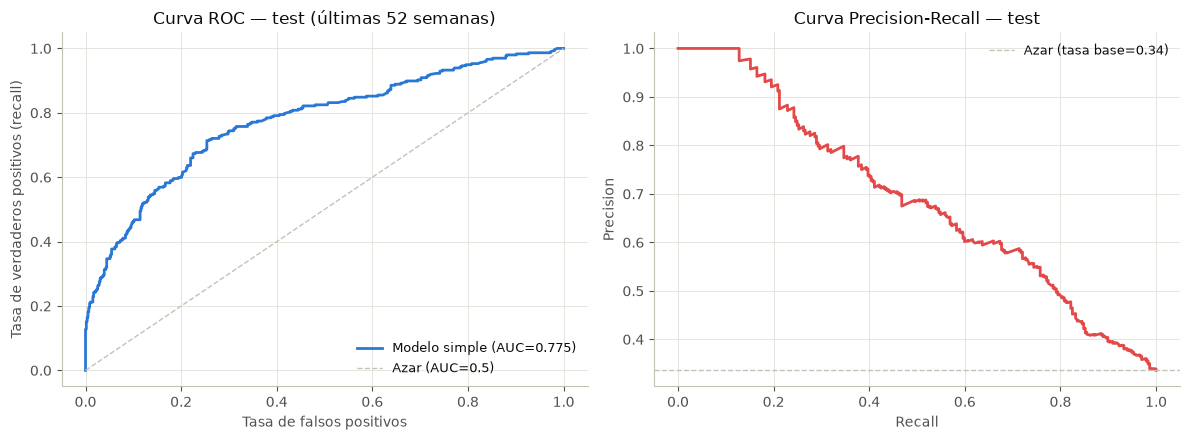

In [7]:
fpr, tpr, _ = roc_curve(y_test, proba_test)
roc_auc = auc(fpr, tpr)

prec, rec, umbrales_pr = precision_recall_curve(y_test, proba_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(fpr, tpr, color=AZUL, linewidth=2, label=f"Modelo simple (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="#c3c2b7", linewidth=1, linestyle="--", label="Azar (AUC=0.5)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos (recall)")
ax.set_title("Curva ROC — test (últimas 52 semanas)")
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
ax.plot(rec, prec, color=ROJO, linewidth=2)
ax.axhline((y_test.mean()), color="#c3c2b7", linewidth=1, linestyle="--", label=f"Azar (tasa base={y_test.mean():.2f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall — test")
ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


## 6. Comparación contra el modelo optimizado de producción

El modelo de arriba usó hiperparámetros fijos, sin ninguna búsqueda. El
modelo de producción (`scripts/modelo_final_dengue_grave.pkl`) sí pasó por
~100 trials de Optuna con `TimeSeriesSplit` interno (`training/optimization.py`)
y su umbral fue calibrado explícitamente (ver `BITACORA_EXPERIMENTOS.txt`,
experimento 10, y `CHANGELOG.md` [2026-07-06]). Evaluamos ambos sobre el
**mismo split de test** para que la comparación sea justa.


In [8]:
with open(RAIZ_PROYECTO / "scripts" / "modelo_final_dengue_grave.pkl", "rb") as f:
    modelo_produccion = pickle.load(f)
with open(RAIZ_PROYECTO / "scripts" / "metadata_modelo_grave.json", "r") as f:
    metadata = json.load(f)

FEATURES_PROD = metadata["features_ordenadas"]
UMBRAL_PROD = metadata["umbral_calibrado"]

X_test_prod = X_test[FEATURES_PROD]
proba_test_prod = modelo_produccion.predict_proba(X_test_prod)[:, 1]
pred_test_prod = (proba_test_prod >= UMBRAL_PROD).astype(int)

resumen = pd.DataFrame([
    {
        "modelo": "Simple (sin Optuna, umbral 0.50)",
        "roc_auc": roc_auc_score(y_test, proba_test),
        "f1.5": fbeta_score(y_test, pred_test_050, beta=1.5),
        "precision": ((pred_test_050 == 1) & (y_test.values == 1)).sum() / max(pred_test_050.sum(), 1),
        "recall": ((pred_test_050 == 1) & (y_test.values == 1)).sum() / max(y_test.sum(), 1),
        "umbral": 0.50,
    },
    {
        "modelo": "Producción (Optuna + umbral calibrado)",
        "roc_auc": roc_auc_score(y_test, proba_test_prod),
        "f1.5": fbeta_score(y_test, pred_test_prod, beta=1.5),
        "precision": ((pred_test_prod == 1) & (y_test.values == 1)).sum() / max(pred_test_prod.sum(), 1),
        "recall": ((pred_test_prod == 1) & (y_test.values == 1)).sum() / max(y_test.sum(), 1),
        "umbral": UMBRAL_PROD,
    },
])
resumen[["roc_auc", "f1.5", "precision", "recall"]] = resumen[["roc_auc", "f1.5", "precision", "recall"]].round(3)
resumen


,modelo,roc_auc,f1.5,precision,recall,umbral
0,"Simple (sin Optuna, umbral 0.50)",0.775,0.471,0.729,0.407,0.50
1,Producción (Optuna + umbral calibrado),0.791,0.681,0.525,0.785,0.12


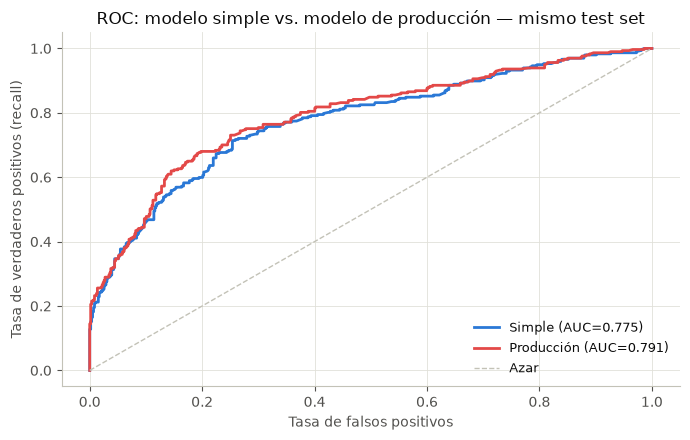

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(fpr, tpr, color=AZUL, linewidth=2, label=f"Simple (AUC={roc_auc_score(y_test, proba_test):.3f})")

fpr_p, tpr_p, _ = roc_curve(y_test, proba_test_prod)
ax.plot(fpr_p, tpr_p, color=ROJO, linewidth=2, label=f"Producción (AUC={roc_auc_score(y_test, proba_test_prod):.3f})")
ax.plot([0, 1], [0, 1], color="#c3c2b7", linewidth=1, linestyle="--", label="Azar")

ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos (recall)")
ax.set_title("ROC: modelo simple vs. modelo de producción — mismo test set")
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 7. Conclusión

- El entrenamiento simple (sin búsqueda de hiperparámetros) ya captura la
  mayor parte de la señal — el ROC-AUC no está lejos del modelo de
  producción, lo cual es consistente con lo documentado en
  `docs/conclusiones.md` (hallazgo 3): la mayoría del poder predictivo viene
  de la ingeniería de variables (`persistencia_alerta_*`, contagio espacial),
  no de un ajuste fino de hiperparámetros.
- Donde sí se nota la diferencia es en el **balance precision/recall al
  umbral operativo**: el modelo de producción no usa 0.50 como corte, sino un
  umbral calibrado explícitamente (0.12) más una confirmación temporal de 2
  semanas — ambas decisiones son las que llevan el sistema al punto de
  operación real (recall≈0.70, ver `BITACORA_EXPERIMENTOS.txt` experimentos
  9 y 10), no la optimización de hiperparámetros en sí.
- Esto confirma la lectura de `docs/conclusiones.md`: la próxima mejora real
  de precision no va a salir de afinar más el modelo o sus hiperparámetros,
  sino de datos nuevos.
